# STEP 1 : IMPORT LIBRARTES


In [136]:
# ─────────────────────────────────────────────
# SECTION 1 : IMPORTS
# ─────────────────────────────────────────────
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)



# STEP 2 : CONFIGURATION

In [137]:
# ─────────────────────────────────────────────
# SECTION 2 : CONFIGURATION
# ─────────────────────────────────────────────


DATASET_PATH = "."

#DATASET_PATH = "animals"          # ← change if needed
IMG_SIZE     = (64, 64)           # resize target (width, height)
TEST_SIZE    = 0.20               # 80 % train / 20 % test
RANDOM_STATE = 42
MAX_PER_CLASS = 500               # cap per class (speed vs accuracy trade-off)


# STEP 3 : HELPER FUNCTIONS


In [138]:
# ─────────────────────────────────────────────
# SECTION 3 : HELPER FUNCTIONS
# ─────────────────────────────────────────────

def load_images_from_folder(folder: str, label: str,
                             img_size: tuple, max_images: int) -> tuple:
    """
    Read images from *folder*, resize them to *img_size*,
    convert to flattened grayscale numpy arrays.

    Returns
    -------
    images : list[np.ndarray]  – flattened pixel arrays
    labels : list[str]         – repeated label string
    """
    images, labels = [], []
    supported = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(supported)][:max_images]

    for fname in files:
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path).convert("L")          # grayscale
            img = img.resize(img_size, Image.LANCZOS)
            images.append(np.array(img).flatten())        # 1-D vector
            labels.append(label)
        except Exception as exc:
            print(f"  [WARN] Skipping {fname}: {exc}")

    return images, labels


def plot_sample_images(X_raw: list, y_raw: list,
                       img_size: tuple, n: int = 8) -> None:
    """Display a small grid of sample images from the dataset."""
    fig, axes = plt.subplots(2, n // 2, figsize=(14, 5))
    fig.suptitle("Sample Dataset Images", fontsize=14, fontweight="bold")
    indices = np.random.choice(len(X_raw), n, replace=False)
    for ax, idx in zip(axes.flat, indices):
        ax.imshow(X_raw[idx].reshape(img_size), cmap="gray")
        ax.set_title(y_raw[idx], fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=100)
    plt.show()
    print("  [INFO] Sample image grid saved → sample_images.png")


def plot_confusion_matrix(cm: np.ndarray, classes: list) -> None:
    """Pretty-print the confusion matrix as a heatmap."""
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, linecolor="white")
    plt.title("Confusion Matrix", fontsize=13, fontweight="bold")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=100)
    plt.show()
    print("  [INFO] Confusion matrix saved → confusion_matrix.png")


def plot_class_distribution(y: list) -> None:
    """Bar chart of class counts."""
    unique, counts = np.unique(y, return_counts=True)
    plt.figure(figsize=(5, 4))
    plt.bar(unique, counts, color=["steelblue", "coral"], edgecolor="black")
    plt.title("Class Distribution", fontsize=13, fontweight="bold")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    for u, c in zip(unique, counts):
        plt.text(u, c + 2, str(c), ha="center", fontweight="bold")
    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=100)
    plt.show()
    print("  [INFO] Class distribution chart saved → class_distribution.png")

# STEP 4 : LOAD DATASET


In [139]:
# ─────────────────────────────────────────────
# SECTION 4 : LOAD DATASET
# ─────────────────────────────────────────────
cat_folder = os.path.join(DATASET_PATH, "cat")
dog_folder = os.path.join(DATASET_PATH, "dog")

# Validate folders
for folder, name in [(cat_folder, "cat"), (dog_folder, "dog")]:
    if not os.path.isdir(folder):
        raise FileNotFoundError(
            f"Folder not found: '{folder}'\n"
            f"Make sure DATASET_PATH='{DATASET_PATH}' is correct "
            f"and contains '{name}/' sub-folder."
        )

cat_images, cat_labels = load_images_from_folder(
    cat_folder, "cat", IMG_SIZE, MAX_PER_CLASS
)
dog_images, dog_labels = load_images_from_folder(
    dog_folder, "dog", IMG_SIZE, MAX_PER_CLASS
)

X_raw = cat_images + dog_images
y_raw = cat_labels + dog_labels

print(f"  Cats loaded : {len(cat_images)}")
print(f"  Dogs loaded : {len(dog_images)}")
print(f"  Total       : {len(X_raw)}")


  Cats loaded : 500
  Dogs loaded : 500
  Total       : 1000


# STEP 5 : VISUALISE DATASET


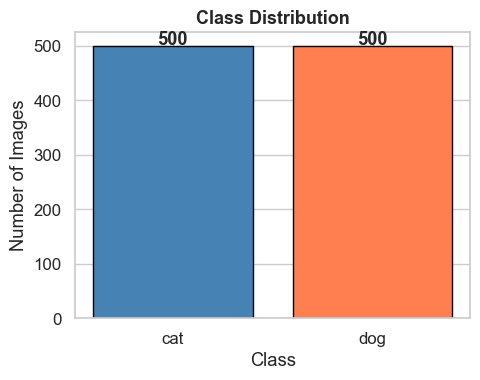

  [INFO] Class distribution chart saved → class_distribution.png


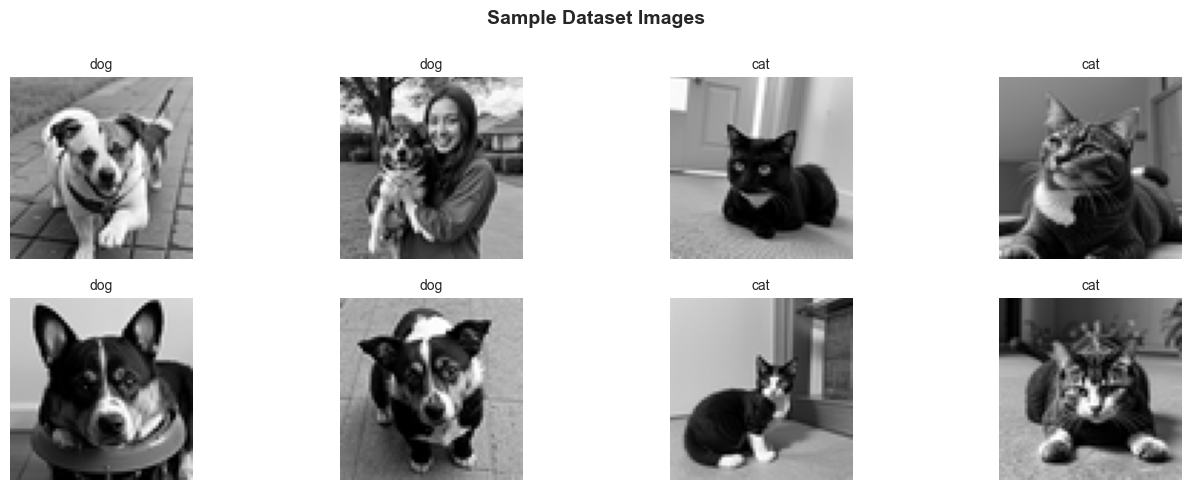

  [INFO] Sample image grid saved → sample_images.png


In [140]:
# ─────────────────────────────────────────────
# SECTION 5 : VISUALISE DATASET
# ─────────────────────────────────────────────
plot_class_distribution(y_raw)
plot_sample_images(X_raw, y_raw, IMG_SIZE, n=8)

# STEP 6 : PRE-PROCESSING


In [141]:
# ─────────────────────────────────────────────
# SECTION 6 : PRE-PROCESSING
# ─────────────────────────────────────────────
X = np.array(X_raw, dtype=np.float32)
y_str = np.array(y_raw)

# Encode labels → 0 (cat) / 1 (dog)
le = LabelEncoder()
y = le.fit_transform(y_str)
print(f"  Label mapping : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"  Training samples : {X_train.shape[0]}")
print(f"  Testing  samples : {X_test.shape[0]}")

# Feature scaling (zero-mean, unit-variance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("  Feature scaling  : done (StandardScaler)")


  Label mapping : {np.str_('cat'): np.int64(0), np.str_('dog'): np.int64(1)}
  Training samples : 800
  Testing  samples : 200
  Feature scaling  : done (StandardScaler)


# STEP 7 : TRAIN SVM MODEL

In [142]:
# ─────────────────────────────────────────────
# SECTION 7 : TRAIN SVM MODEL
# ─────────────────────────────────────────────

svm_model = SVC(
    kernel="rbf",          # Radial Basis Function kernel
    C=10,                  # regularisation strength
    gamma="scale",         # kernel coefficient
    random_state=RANDOM_STATE,
    verbose=False,
)

t0 = time.time()
svm_model.fit(X_train, y_train)
train_time = time.time() - t0
print(f"  SVM training complete in {train_time:.2f} seconds")
print(f"  Kernel : {svm_model.kernel}  |  C : {svm_model.C}  |  Gamma : {svm_model.gamma}")


  SVM training complete in 1.39 seconds
  Kernel : rbf  |  C : 10  |  Gamma : scale


# STEP 8 : EVALUATE MODEL


In [143]:
# ─────────────────────────────────────────────
# SECTION 8 : EVALUATE MODEL
# ─────────────────────────────────────────────

y_pred = svm_model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)
report    = classification_report(y_test, y_pred,
                                   target_names=le.classes_)

print(f"\n  ✔  Test Accuracy : {accuracy * 100:.2f} %")
print("\n  Classification Report :\n")
print(report)


  ✔  Test Accuracy : 79.00 %

  Classification Report :

              precision    recall  f1-score   support

         cat       0.79      0.79      0.79       100
         dog       0.79      0.79      0.79       100

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.79       200



# STEP 9 : CONFUSION MATRIX PLOT


[STEP 6] Plotting confusion matrix …


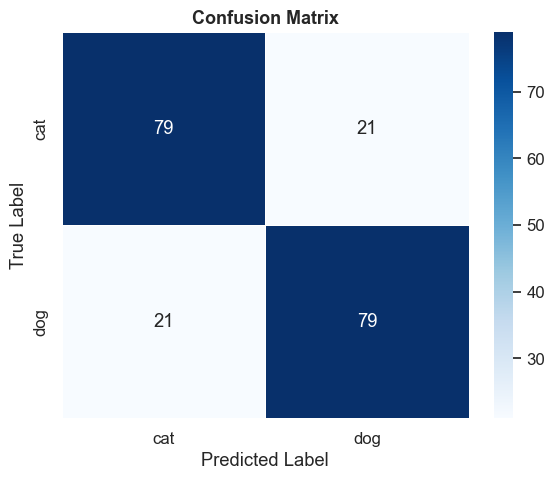

  [INFO] Confusion matrix saved → confusion_matrix.png


In [144]:
# ─────────────────────────────────────────────
# SECTION 9 : CONFUSION MATRIX PLOT
# ─────────────────────────────────────────────
print("[STEP 6] Plotting confusion matrix …")
plot_confusion_matrix(cm, list(le.classes_))

# STEP 10 : OPTIONAL — HYPERPARAMETER TUNING

In [145]:
# ─────────────────────────────────────────────
# SECTION 10 : OPTIONAL — HYPERPARAMETER TUNING
#              (comment out to skip; takes longer)
# ─────────────────────────────────────────────
RUN_GRID_SEARCH = False    # ← set True to enable

if RUN_GRID_SEARCH:
    print("\n[STEP 7] Hyperparameter tuning via GridSearchCV …")
    param_grid = {
        "C"     : [0.1, 1, 10, 100],
        "gamma" : ["scale", "auto", 0.001, 0.01],
        "kernel": ["rbf", "poly"],
    }
    grid_search = GridSearchCV(
        SVC(random_state=RANDOM_STATE),
        param_grid,
        cv=3,
        n_jobs=-1,
        verbose=2,
    )
    grid_search.fit(X_train, y_train)
    best = grid_search.best_estimator_
    best_acc = accuracy_score(y_test, best.predict(X_test))
    print(f"  Best params   : {grid_search.best_params_}")
    print(f"  Best accuracy : {best_acc * 100:.2f} %")
else:
    print("\nHyperparameter tuning : SKIPPED  "
          "(set RUN_GRID_SEARCH = True to enable)")


Hyperparameter tuning : SKIPPED  (set RUN_GRID_SEARCH = True to enable)


# STEP 11 : PREDICT A SINGLE NEW IMAGE


  Demo image : .\cat\00000-4122619873.png
  Prediction : CAT


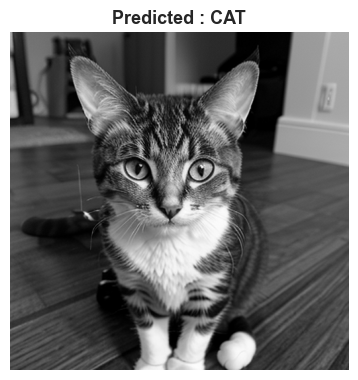

  [INFO] Prediction demo saved → prediction_demo.png


In [146]:
# ─────────────────────────────────────────────
# SECTION 11 : PREDICT A SINGLE NEW IMAGE
# ─────────────────────────────────────────────

def predict_image(image_path: str) -> str:
    """
    Load one image from disk and return the predicted class label.

    Parameters
    ----------
    image_path : str  – path to any cat or dog image

    Returns
    -------
    str – 'cat' or 'dog'
    """
    img = Image.open(image_path).convert("L")
    img = img.resize(IMG_SIZE, Image.LANCZOS)
    vec = np.array(img).flatten().reshape(1, -1).astype(np.float32)
    vec = scaler.transform(vec)
    pred = svm_model.predict(vec)
    return le.inverse_transform(pred)[0]


# --- Demo: pick the FIRST image found in cat/ or dog/ folders ---
demo_path = None
for folder in [cat_folder, dog_folder]:
    files = [f for f in os.listdir(folder)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if files:
        demo_path = os.path.join(folder, files[0])
        break

if demo_path:
    result = predict_image(demo_path)
    print(f"  Demo image : {demo_path}")
    print(f"  Prediction : {result.upper()}")

    # Show the demo image with its prediction
    demo_img = Image.open(demo_path).convert("L")
    plt.figure(figsize=(4, 4))
    plt.imshow(demo_img, cmap="gray")
    plt.title(f"Predicted : {result.upper()}", fontsize=13, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("prediction_demo.png", dpi=100)
    plt.show()
    print("  [INFO] Prediction demo saved → prediction_demo.png")
else:
    print("  [WARN] No demo image found.") 

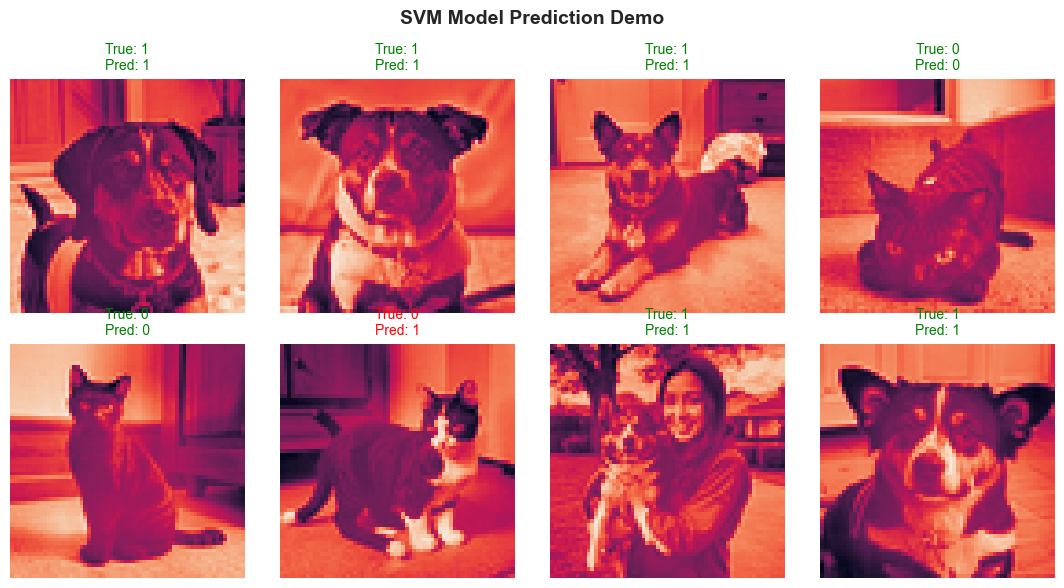

Saved → .\prediction_demo.png



In [147]:
if 'X_test' in locals() and 'y_test' in locals() and 'y_pred' in locals():
    fig, axes = plt.subplots(2, 4, figsize=(11, 6))
    axes = axes.flatten()
    
    # Random 8 indices select karna test set se
    sample_indices = random.sample(range(len(X_test)), min(8, len(X_test)))
    
    for i, idx in enumerate(sample_indices):
        # Image shape handle karna (Flat array ko wapas $64 \times 64$ mein lana)
        img_shape = X_test[idx].reshape(IMG_SIZE[0], IMG_SIZE[1], -1) if X_test[idx].ndim == 1 else X_test[idx]
        
        axes[i].imshow(img_shape)
        
        true_lbl = y_test[idx]
        pred_lbl = y_pred[idx]
        
        # Agar prediction sahi ho to green text, galat ho to red text
        color = "green" if true_lbl == pred_lbl else "red"
        
        axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl}", fontsize=10, color=color)
        axes[i].axis('off')
        
    plt.suptitle("SVM Model Prediction Demo", fontsize=14, fontweight="bold")
    plt.tight_layout()
    
    save_path5 = os.path.join(SAVE_DIR, "prediction_demo.png")
    plt.savefig(save_path5, dpi=120)
    plt.show()
    print(f"Saved → {save_path5}\n")
else:
    print("Skipped: Model evaluation variables (X_test, y_test, y_pred) missing hain.")

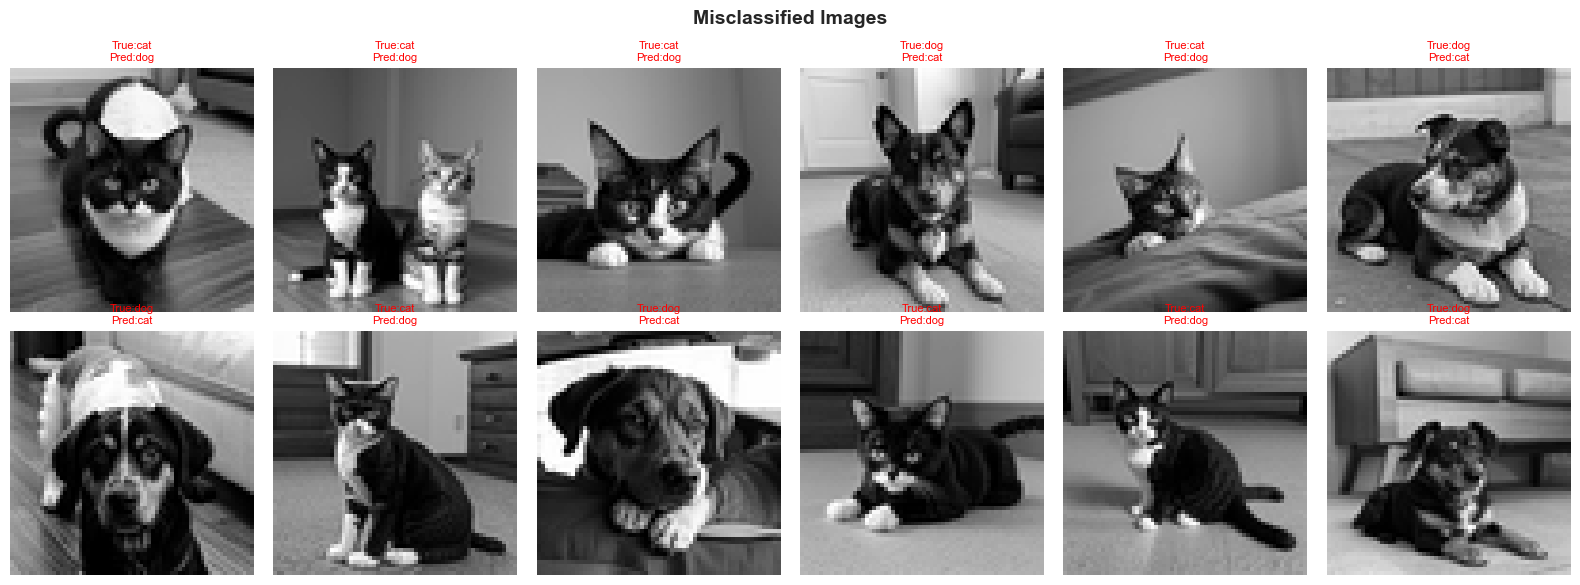

   Saved → ./14_misclassified_images.png



In [148]:
# ════════════════════════════════════════════════
#  Misclassified Images Grid
# ════════════════════════════════════════════════

misclassified = np.where(y_pred != y_test)[0]
show_n        = min(12, len(misclassified))

if show_n > 0:
    fig, axes = plt.subplots(2, 6, figsize=(16, 6))
    fig.suptitle("Misclassified Images",
                 fontsize=14, fontweight="bold")
    for i, ax in enumerate(axes.flat):
        if i < show_n:
            idx  = misclassified[i]
            true = le.classes_[y_test[idx]]
            pred_lbl = le.classes_[y_pred[idx]]
            ax.imshow(
                scaler.inverse_transform(
                    X_test[idx].reshape(1, -1)
                ).reshape(IMG_SIZE),
                cmap="gray",
            )
            ax.set_title(f"True:{true}\nPred:{pred_lbl}",
                         fontsize=8, color="red")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/misclassified_images.png", dpi=120)
    plt.show()
    print(f"   Saved → {SAVE_DIR}/14_misclassified_images.png\n")
else:
    print("   No misclassified images found (perfect model!).\n")

# GRAPHS VISUALIZATION

#  Precision-Recall Curve


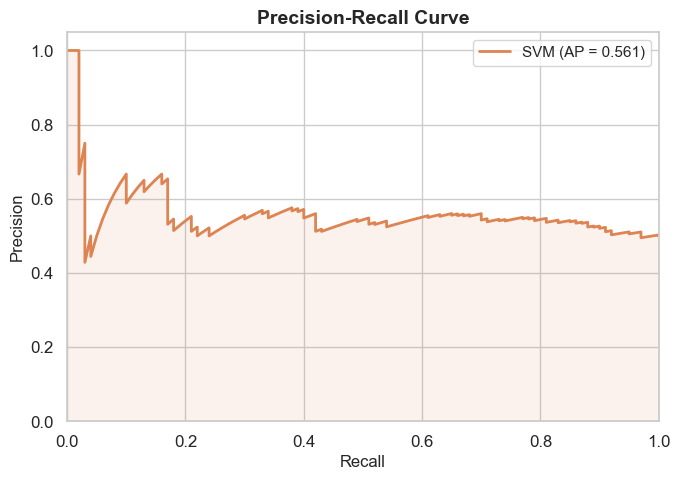

In [149]:
# ════════════════════════════════════════════════
#  Precision-Recall Curve
# ════════════════════════════════════════════════

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color="#DD8452", lw=2,
        label=f"SVM (AP = {avg_precision:.3f})")
ax.fill_between(recall_vals, precision_vals, alpha=0.1, color="#DD8452")
ax.set_title("Precision-Recall Curve",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/precision_recall_curve.png", dpi=120)
plt.show()


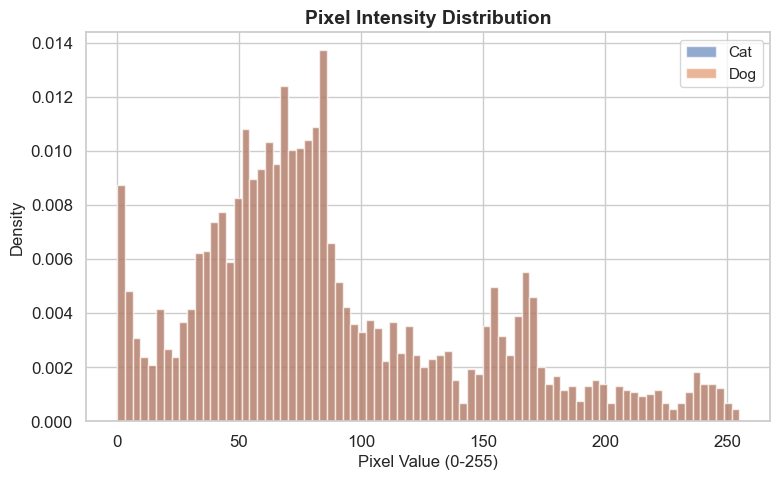

In [150]:

# 1. Target data ko flatten karna
cat_pixels = X_raw[y_raw == "cat"].flatten()
dog_pixels = X_raw[y_raw == "dog"].flatten()

# 2. Safe Dynamic Sample Size (Masla yahan hal hua hai)
desired_sample = 50_000
cat_sample_size = min(desired_sample, len(cat_pixels))
dog_sample_size = min(desired_sample, len(dog_pixels))

# 3. Random choice lagana safe size ke sath
cat_sample = np.random.choice(cat_pixels, cat_sample_size, replace=False)
dog_sample = np.random.choice(dog_pixels, dog_sample_size, replace=False)

# 4. Plotting Graph
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(cat_sample, bins=80, alpha=0.6, color="#4C72B0", label="Cat", density=True)
ax.hist(dog_sample, bins=80, alpha=0.6, color="#DD8452", label="Dog", density=True)

ax.set_title("Pixel Intensity Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Pixel Value (0-255)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()

# Save aur show karna
os.makedirs(SAVE_DIR, exist_ok=True) # Ensure directory exists
plt.savefig(f"{SAVE_DIR}/pixel_intensity.png", dpi=120)
plt.show()


#  Learning Curve


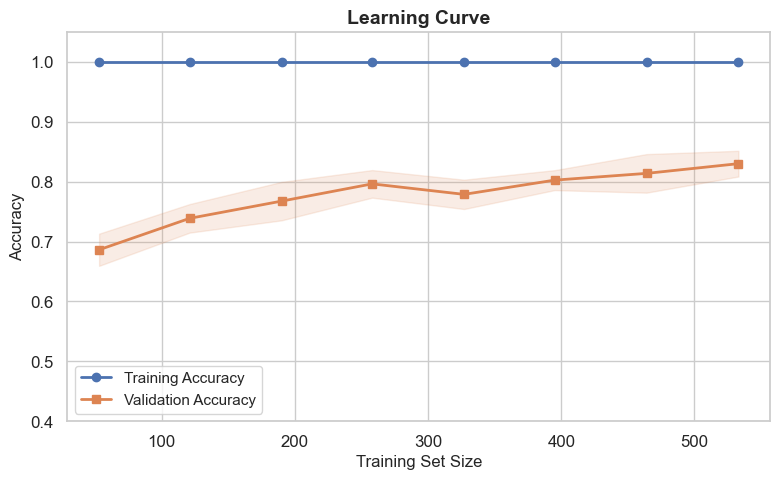

In [151]:
# ════════════════════════════════════════════════
#  Learning Curve
# ════════════════════════════════════════════════

train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE),
    X_train, y_train,
    cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy",
)
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", color="#4C72B0",
        lw=2, label="Training Accuracy")
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std, alpha=0.15, color="#4C72B0")
ax.plot(train_sizes, val_mean, "s-", color="#DD8452",
        lw=2, label="Validation Accuracy")
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std, alpha=0.15, color="#DD8452")
ax.set_title("Learning Curve", fontsize=14, fontweight="bold")
ax.set_xlabel("Training Set Size", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim([0.4, 1.05])
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/learning_curve.png", dpi=120)
plt.show()


# PCA : 2D Feature Space Scatter Plot


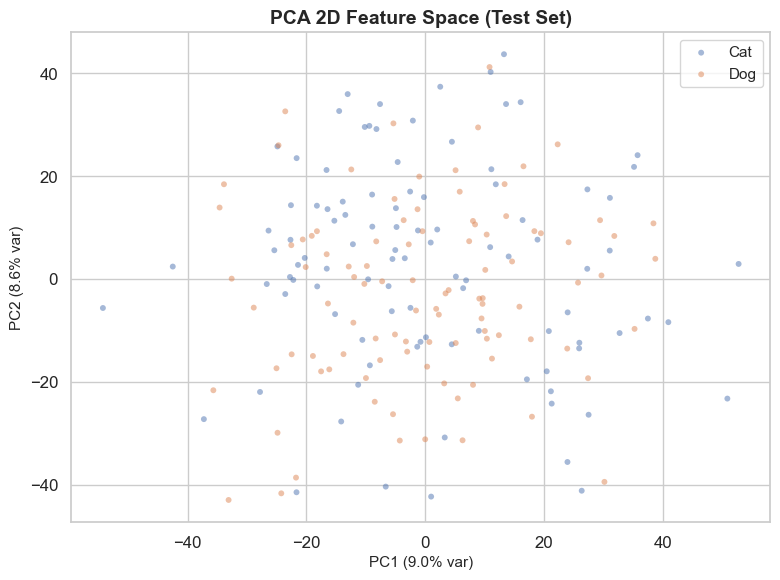

In [152]:
# ════════════════════════════════════════════════
# PCA : 2D Feature Space Scatter Plot
# ════════════════════════════════════════════════

pca    = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca  = pca.fit_transform(X_test)
colors_map = {0: "#4C72B0", 1: "#DD8452"}   # 0=cat, 1=dog
label_map  = {0: "Cat", 1: "Dog"}

fig, ax = plt.subplots(figsize=(8, 6))
for cls in [0, 1]:
    mask = y_test == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors_map[cls], label=label_map[cls],
               alpha=0.5, s=18, edgecolors="none")
ax.set_title("PCA 2D Feature Space (Test Set)",
             fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)",
              fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)",
              fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/pca_scatter.png", dpi=120)
plt.show()


#  PCA : Explained Variance (Scree Plot)


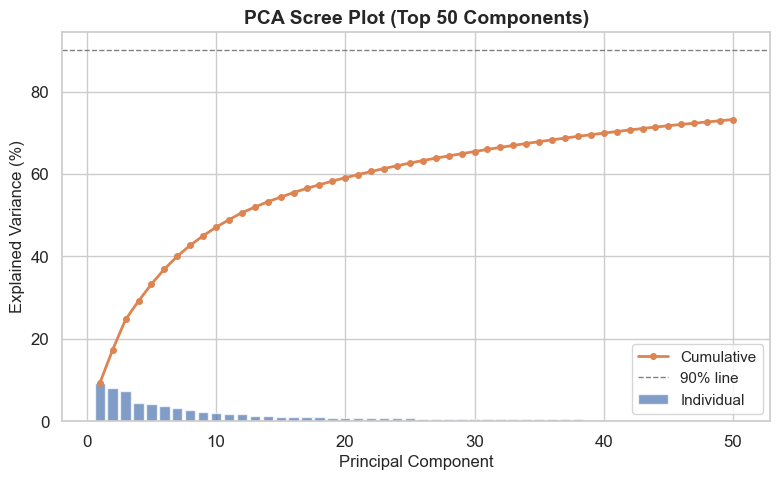

In [153]:
# ════════════════════════════════════════════════
#  PCA : Explained Variance (Scree Plot)
# ════════════════════════════════════════════════

pca_full = PCA(n_components=50, random_state=RANDOM_STATE)
pca_full.fit(X_train)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, 51), pca_full.explained_variance_ratio_ * 100,
       color="#4C72B0", alpha=0.7, label="Individual")
ax.plot(range(1, 51), cumvar, "o-", color="#DD8452",
        lw=2, markersize=4, label="Cumulative")
ax.axhline(90, color="gray", linestyle="--", linewidth=1, label="90% line")
ax.set_title("PCA Scree Plot (Top 50 Components)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Principal Component", fontsize=12)
ax.set_ylabel("Explained Variance (%)", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/pca_scree.png", dpi=120)
plt.show()




#  Prediction Probability Distribution


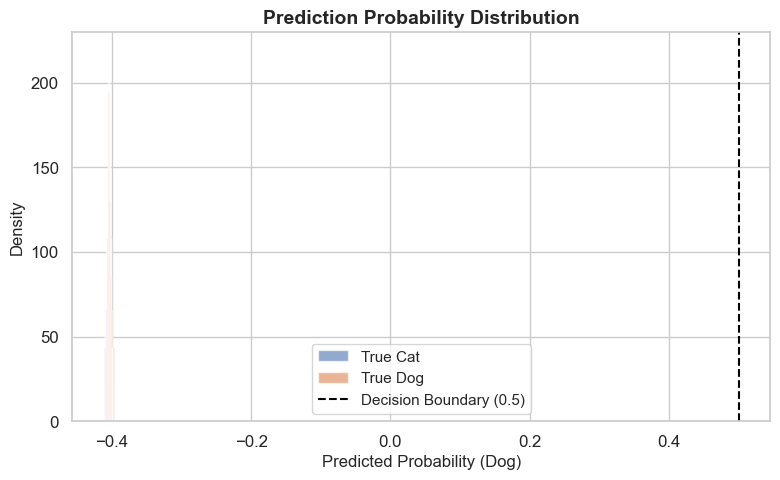

In [154]:
# ════════════════════════════════════════════════
#  Prediction Probability Distribution
# ════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
cat_probs = y_prob[y_test == 0]
dog_probs = y_prob[y_test == 1]
ax.hist(cat_probs, bins=30, alpha=0.6, color="#4C72B0",
        label="True Cat", density=True)
ax.hist(dog_probs, bins=30, alpha=0.6, color="#DD8452",
        label="True Dog", density=True)
ax.axvline(0.5, color="black", linestyle="--",
           linewidth=1.5, label="Decision Boundary (0.5)")
ax.set_title("Prediction Probability Distribution",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Probability (Dog)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/probability_distribution.png", dpi=120)
plt.show()




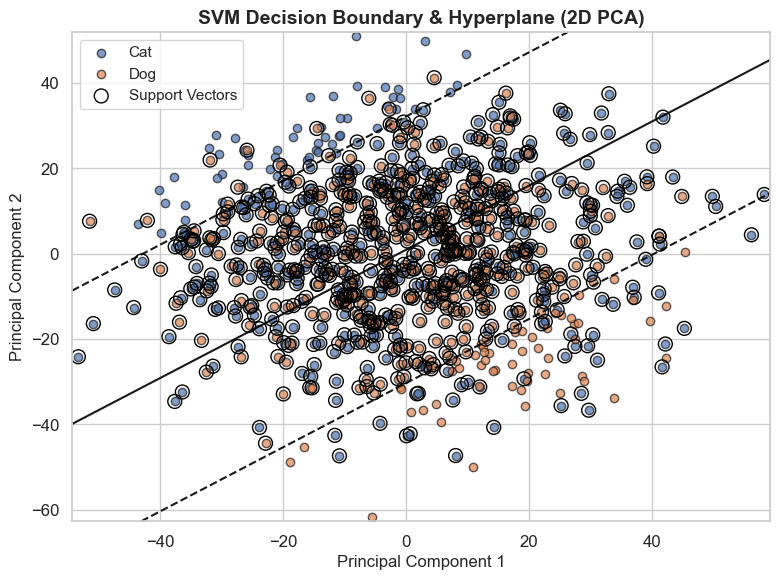

Saved → .\svm_hyperplane.png



In [155]:



# 1. Dimensions kam karna (4096 pixels se sirf 2D components banana)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train)

# 2. Temporary SVM model train karna is 2D data par
svm_2d = SVC(kernel='linear', C=1.0)  
svm_2d.fit(X_train_2d, y_train)

# 3. Graph ki Grid (Meshgrid) taiyar karna
xlim = (X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1)
ylim = (X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1)

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = svm_2d.decision_function(xy).reshape(XX.shape)

# 4. Plotting Setup
fig, ax = plt.subplots(figsize=(8, 6))

# Target Labels ko numpy array mein cast karna
y_train_arr = np.asarray(y_train)

# FIXED: Standard 'or' ki jagah bitwise '|' use kiya element-wise operation ke liye
cat_mask = (y_train_arr == "cat") | (y_train_arr == "0") | (y_train_arr == 0)
dog_mask = (y_train_arr == "dog") | (y_train_arr == "1") | (y_train_arr == 1)

# Data points plot karna
ax.scatter(X_train_2d[cat_mask, 0], X_train_2d[cat_mask, 1], color="#4C72B0", label="Cat", alpha=0.7, edgecolors='k')
ax.scatter(X_train_2d[dog_mask, 0], X_train_2d[dog_mask, 1], color="#DD8452", label="Dog", alpha=0.7, edgecolors='k')

# FIXED: 'rhythms' parameter hata kar standard formatting set ki hai
ax.contour(XX, YY, Z, colors='black', levels=[-1, 0, 1], alpha=0.9, linestyles=['--', '-', '--'])

# Support Vectors ko highlight karna
ax.scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1], s=100,
           linewidths=1, facecolors='none', edgecolors='black', label="Support Vectors")

ax.set_title("SVM Decision Boundary & Hyperplane (2D PCA)", fontsize=14, fontweight="bold")
ax.set_xlabel("Principal Component 1", fontsize=12)
ax.set_ylabel("Principal Component 2", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()

# 5. Save aur Show check
if 'SAVE_DIR' not in locals() and 'SAVE_DIR' not in globals():
    SAVE_DIR = "graphs"
os.makedirs(SAVE_DIR, exist_ok=True)
save_path = os.path.join(SAVE_DIR, "svm_hyperplane.png")

plt.savefig(save_path, dpi=120)
plt.show()

print(f"Saved → {save_path}\n")